# Notebook 03: Axis 2A — End-to-End Extraction (Flan-T5-Large)
## EBM-NLP Dataset | Sentence-Level Input

This notebook is the FIRST experiment for Axis 2A.
It tests zero-shot and few-shot prompting using Flan-T5-Large
on individual sentences (not full abstracts).

**Model:** google/flan-t5-large
**Input:** Single sentences from sentences_df.csv
**Key finding:** Few-shot HURT performance due to small model
size and limited context window.

**Required file:** sentences_df.csv


**This notebook led to Notebook 04** where we tested a larger
model (Qwen) on full abstracts to investigate why few-shot failed.

In [1]:
!pip install transformers torch datasets scikit-learn -q

print("Libraries installed!")

Libraries installed!


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("sentences_df.csv")

print(f"Loaded {len(df)} sentences")
print(f"\nLabel distribution:")
print(df["label"].value_counts())
print(f"\nExample sentences:")
print(df["sentence"].head(3).values)

Loaded 5590 sentences

Label distribution:
label
outcomes         2195
interventions    1406
none             1220
participants      769
Name: count, dtype: int64

Example sentences:
['[ Triple therapy regimens involving H2 blockaders for therapy of Helicobacter pylori infections ] .'
 'Comparison of ranitidine and lansoprazole in short-term low-dose triple therapy for Helicobacter pylori infection .'
 'To evaluate the efficacy and safety of two 1-week low-dose triple-therapy drug regimens involving antisecretory drugs for Helicobacter pylori infection , 99 patients with H. pylori infection were treated with either lansoprazole ( LPZ ) or ranitidine ( RNT ) used together with clarithromycin ( CAM ) and metrinidazole ( MTZ ) .']


In [3]:
# AXIS 2A — END-TO-END EXTRACTION
# HYPOTHESIS (Written BEFORE experiments)

hypothesis = """
HYPOTHESIS:

We hypothesise that Few-shot prompting will significantly
outperform Zero-shot prompting for PICO extraction because:

1. PICO categories have specific medical definitions that
   a general LLM may not naturally understand without examples.
   Showing 3 worked examples clarifies exactly what counts
   as Population vs Intervention vs Outcome.

2. Zero-shot will struggle most with the Outcome field
   because outcome language is most varied — it includes
   percentages, p-values, clinical measurements and
   qualitative descriptions.

3. Both approaches will perform better on Intervention
   extraction than Population or Outcome, because drug
   names and dosages are distinctive and easy to spot.

4. Neither approach will match fine-tuned models (Axis 1B)
   because they have no task-specific training on EBM-NLP.

Expected ranking: Few-shot > Zero-shot
Expected best field: Interventions
Expected worst field: Outcomes
"""

print(hypothesis)


HYPOTHESIS:

We hypothesise that Few-shot prompting will significantly
outperform Zero-shot prompting for PICO extraction because:

1. PICO categories have specific medical definitions that
   a general LLM may not naturally understand without examples.
   Showing 3 worked examples clarifies exactly what counts
   as Population vs Intervention vs Outcome.

2. Zero-shot will struggle most with the Outcome field
   because outcome language is most varied — it includes
   percentages, p-values, clinical measurements and
   qualitative descriptions.

3. Both approaches will perform better on Intervention
   extraction than Population or Outcome, because drug
   names and dosages are distinctive and easy to spot.

4. Neither approach will match fine-tuned models (Axis 1B)
   because they have no task-specific training on EBM-NLP.

Expected ranking: Few-shot > Zero-shot
Expected best field: Interventions
Expected worst field: Outcomes



In [4]:
from transformers import T5ForConditionalGeneration, T5Tokenizer
import torch

print(" Loading Flan-T5 model...")
print("   (This will take 2-3 minutes - downloading model)")

# Load model and tokenizer
model_name = "google/flan-t5-large"
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"\n Model loaded successfully!")
print(f"   Running on: {device}")
print(f"   Model: {model_name}")

 Loading Flan-T5 model...
   (This will take 2-3 minutes - downloading model)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


 Model loaded successfully!
   Running on: cuda
   Model: google/flan-t5-large


In [5]:
# HELPER FUNCTION — Ask the model a question

def ask_model(prompt, max_length=200):
    """
    Sends a prompt to Flan-T5 and returns the response.

    prompt     = the question/instruction we give the model
    max_length = maximum words in the response
    """
    # Convert prompt text into numbers the model understands
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=512,
        truncation=True,
        padding=True
    ).to(device)

    # Generate response
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=4,
            early_stopping=True
        )

    # Convert numbers back to text
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return response

# Test it works with a simple question
test_response = ask_model("What is the capital of France?")
print(f" Model test response: {test_response}")
print("\nModel is working correctly and ready for PICO extraction!")

 Model test response: paris disambiguation

Model is working correctly and ready for PICO extraction!


In [6]:
# PART 1 — ZERO-SHOT EXTRACTION

def zero_shot_extract(abstract):
    """
    Extracts PICO fields from an abstract using
    ZERO examples — just instructions.
    """
    prompt = f"""Extract medical information from this clinical trial abstract.

Abstract: {abstract}

Instructions:
- Population: Who were the patients or participants studied?
- Intervention: What treatment, drug or procedure was given?
- Outcome: What results or measurements were reported?

If a field is not mentioned, write "not found".

Population:"""

    # Get population
    population = ask_model(prompt, max_length=100)

    # Get intervention
    prompt_i = prompt.replace("Population:", "Intervention:")
    intervention = ask_model(prompt_i, max_length=100)

    # Get outcome
    prompt_o = prompt.replace("Population:", "Outcome:")
    outcome = ask_model(prompt_o, max_length=100)

    return {
        "population": population,
        "intervention": intervention,
        "outcome": outcome
    }

# Test on one abstract first
test_abstract = """99 patients with H. pylori infection were treated
with either lansoprazole or ranitidine used together with
clarithromycin and metronidazole. The cure rate was 88%
in the lansoprazole group and 92% in the ranitidine group."""

print(" TESTING ZERO-SHOT ON ONE ABSTRACT:")
print("="*60)
print(f"Abstract: {test_abstract}")
print("="*60)

result = zero_shot_extract(test_abstract)

print(f"\n EXTRACTED PICO:")
print(f"  Population:    {result['population']}")
print(f"  Intervention:  {result['intervention']}")
print(f"  Outcome:       {result['outcome']}")

 TESTING ZERO-SHOT ON ONE ABSTRACT:
Abstract: 99 patients with H. pylori infection were treated
with either lansoprazole or ranitidine used together with
clarithromycin and metronidazole. The cure rate was 88%
in the lansoprazole group and 92% in the ranitidine group.

 EXTRACTED PICO:
  Population:    not found
  Intervention:  Outcome
  Outcome:       not found


In [7]:
# IMPROVED ZERO-SHOT PROMPT

def zero_shot_extract(abstract):
    """
    Extracts PICO fields using improved zero-shot prompting.
    Each field gets its own focused question.
    """

    # Question for Population
    prompt_p = f"""Read this medical abstract and answer the question.

Abstract: {abstract}

Question: Who are the patients or participants in this study?
Describe their medical condition and how many there are.
Answer in one sentence."""

    # Question for Intervention
    prompt_i = f"""Read this medical abstract and answer the question.

Abstract: {abstract}

Question: What is the main treatment, drug or medical procedure
being tested in this study?
Answer in one sentence."""

    # Question for Outcome
    prompt_o = f"""Read this medical abstract and answer the question.

Abstract: {abstract}

Question: What were the main results or findings measured
in this study? Include any numbers or percentages mentioned.
Answer in one sentence."""

    population    = ask_model(prompt_p, max_length=100)
    intervention  = ask_model(prompt_i, max_length=100)
    outcome       = ask_model(prompt_o, max_length=100)

    return {
        "population":   population,
        "intervention": intervention,
        "outcome":      outcome
    }

# Test on same abstract
test_abstract = """99 patients with H. pylori infection were treated
with either lansoprazole or ranitidine used together with
clarithromycin and metronidazole. The cure rate was 88%
in the lansoprazole group and 92% in the ranitidine group."""

print(" TESTING IMPROVED ZERO-SHOT:")
print("="*60)
print(f"Abstract: {test_abstract}")
print("="*60)

result = zero_shot_extract(test_abstract)

print(f"\n EXTRACTED PICO:")
print(f"  Population:    {result['population']}")
print(f"  Intervention:  {result['intervention']}")
print(f"  Outcome:       {result['outcome']}")

 TESTING IMPROVED ZERO-SHOT:
Abstract: 99 patients with H. pylori infection were treated
with either lansoprazole or ranitidine used together with
clarithromycin and metronidazole. The cure rate was 88%
in the lansoprazole group and 92% in the ranitidine group.

 EXTRACTED PICO:
  Population:    H. pylori
  Intervention:  (d).
  Outcome:       The cure rate was 88%


In [8]:
# FURTHER IMPROVED ZERO-SHOT PROMPT
# FINAL VERSION of zero_shot_extract — V3
# (Earlier versions in cells above show our prompt iteration process)


def zero_shot_extract(abstract):

    # Population prompt
    prompt_p = f"""Read this medical abstract carefully.

Abstract: {abstract}

Question: Who are the patients in this study?
Write the number of patients and their medical condition.
Example answer format: "X patients with [condition]"
Answer:"""

    # Intervention prompt - more specific
    prompt_i = f"""Read this medical abstract carefully.

Abstract: {abstract}

Question: List ALL the drugs, treatments or procedures
being tested or compared in this study.
Write only the drug or treatment names.
Answer:"""

    # Outcome prompt
    prompt_o = f"""Read this medical abstract carefully.

Abstract: {abstract}

Question: What were the numerical results or findings
of this study? Include percentages or measurements.
Answer:"""

    population   = ask_model(prompt_p, max_length=100)
    intervention = ask_model(prompt_i, max_length=100)
    outcome      = ask_model(prompt_o, max_length=100)

    return {
        "population":   population,
        "intervention": intervention,
        "outcome":      outcome
    }

# Test on same abstract so we can compare
test_abstract = """99 patients with H. pylori infection were treated
with either lansoprazole or ranitidine used together with
clarithromycin and metronidazole. The cure rate was 88%
in the lansoprazole group and 92% in the ranitidine group."""

print(" TESTING ZERO-SHOT V3:")
print("="*60)
print(f"Abstract:\n{test_abstract}")
print("="*60)

result = zero_shot_extract(test_abstract)

print(f"\n EXTRACTED PICO:")
print(f"  Population:    {result['population']}")
print(f"  Intervention:  {result['intervention']}")
print(f"  Outcome:       {result['outcome']}")

print("\n NOTES FOR REPORT:")
print("  - This is our FINAL zero-shot prompt design")
print("  - Each field gets a separate focused question")
print("  - No examples provided (pure zero-shot)")

 TESTING ZERO-SHOT V3:
Abstract:
99 patients with H. pylori infection were treated
with either lansoprazole or ranitidine used together with
clarithromycin and metronidazole. The cure rate was 88%
in the lansoprazole group and 92% in the ranitidine group.

 EXTRACTED PICO:
  Population:    H. pylori
  Intervention:  clarithromycin and metronidazole
  Outcome:       The cure rate was 88%

 NOTES FOR REPORT:
  - This is our FINAL zero-shot prompt design
  - Each field gets a separate focused question
  - No examples provided (pure zero-shot)


In [9]:
# PART 2 — FEW-SHOT EXTRACTION

# First we need good examples to show the model
# These are REAL examples from our EBM-NLP dataset
# carefully selected to cover different types of trials

FEW_SHOT_EXAMPLES = """
EXAMPLE 1:
Abstract: A total of 200 elderly patients aged over 65 with
type 2 diabetes were randomly assigned to receive either
metformin 500mg twice daily or a placebo for 12 weeks.
Fasting blood glucose levels decreased significantly by
2.3 mmol/L in the metformin group compared to 0.1 mmol/L
in the placebo group.

Population: 200 elderly patients aged over 65 with type 2 diabetes
Intervention: metformin 500mg twice daily vs placebo
Outcome: Fasting blood glucose decreased by 2.3 mmol/L in
metformin group vs 0.1 mmol/L in placebo group

---

EXAMPLE 2:
Abstract: Fifty children aged 4-12 years diagnosed with
acute otitis media were treated with amoxicillin 40mg/kg/day
for 5 days. Pain scores measured using a visual scale
improved from 7.2 to 2.1 after treatment completion.

Population: 50 children aged 4-12 years with acute otitis media
Intervention: amoxicillin 40mg/kg/day for 5 days
Outcome: Pain scores improved from 7.2 to 2.1

---

EXAMPLE 3:
Abstract: We recruited 150 adult patients with moderate
to severe hypertension. Patients received either amlodipine
5mg daily or losartan 50mg daily for 6 months. Systolic
blood pressure reduction was 18mmHg in the amlodipine group
versus 15mmHg in the losartan group.

Population: 150 adult patients with moderate to severe hypertension
Intervention: amlodipine 5mg daily vs losartan 50mg daily
Outcome: Systolic blood pressure reduction of 18mmHg vs 15mmHg
"""

print(" Few-shot examples defined!")
print(f"   3 carefully chosen examples covering:")
print(f"   → Diabetes trial (Example 1)")
print(f"   → Paediatric infection trial (Example 2)")
print(f"   → Hypertension trial (Example 3)")
print(f"\n These examples teach the model:")
print(f"   → What format to use")
print(f"   → What counts as Population vs Intervention vs Outcome")
print(f"   → How to handle multiple drugs being compared")

 Few-shot examples defined!
   3 carefully chosen examples covering:
   → Diabetes trial (Example 1)
   → Paediatric infection trial (Example 2)
   → Hypertension trial (Example 3)

 These examples teach the model:
   → What format to use
   → What counts as Population vs Intervention vs Outcome
   → How to handle multiple drugs being compared


In [10]:
# FEW-SHOT EXTRACTION FUNCTION

def few_shot_extract(abstract):
    """
    Extracts PICO fields using FEW-SHOT prompting.
    Shows the model 3 worked examples before asking
    it to extract from a new abstract.
    """

    # Population prompt with examples
    prompt_p = f"""You are a medical information extraction system.
Study these examples of extracting Population from abstracts:

{FEW_SHOT_EXAMPLES}

Now extract ONLY the Population from this abstract.
Population means: who are the patients, how many,
and what is their medical condition.

Abstract: {abstract}

Population:"""

    # Intervention prompt with examples
    prompt_i = f"""You are a medical information extraction system.
Study these examples of extracting Intervention from abstracts:

{FEW_SHOT_EXAMPLES}

Now extract ONLY the Intervention from this abstract.
Intervention means: all drugs, treatments or procedures
being tested or compared.

Abstract: {abstract}

Intervention:"""

    # Outcome prompt with examples
    prompt_o = f"""You are a medical information extraction system.
Study these examples of extracting Outcome from abstracts:

{FEW_SHOT_EXAMPLES}

Now extract ONLY the Outcome from this abstract.
Outcome means: the main results, measurements or findings
including any numbers or percentages.

Abstract: {abstract}

Outcome:"""

    population   = ask_model(prompt_p, max_length=150)
    intervention = ask_model(prompt_i, max_length=150)
    outcome      = ask_model(prompt_o, max_length=150)

    return {
        "population":   population,
        "intervention": intervention,
        "outcome":      outcome
    }

# Test on SAME abstract as zero-shot so we can directly compare!
test_abstract = """99 patients with H. pylori infection were treated
with either lansoprazole or ranitidine used together with
clarithromycin and metronidazole. The cure rate was 88%
in the lansoprazole group and 92% in the ranitidine group."""

print(" TESTING FEW-SHOT ON SAME ABSTRACT:")
print("="*60)
print(f"Abstract:\n{test_abstract}")
print("="*60)

result_fewshot = few_shot_extract(test_abstract)

print(f"\n FEW-SHOT EXTRACTED PICO:")
print(f"  Population:    {result_fewshot['population']}")
print(f"  Intervention:  {result_fewshot['intervention']}")
print(f"  Outcome:       {result_fewshot['outcome']}")

print("\n ZERO-SHOT EXTRACTED PICO (for comparison):")
result_zeroshot = zero_shot_extract(test_abstract)
print(f"  Population:    {result_zeroshot['population']}")
print(f"  Intervention:  {result_zeroshot['intervention']}")
print(f"  Outcome:       {result_zeroshot['outcome']}")

print("\n DIRECT COMPARISON ON SAME ABSTRACT:")
print("  Zero-shot vs Few-shot — can you see the difference?")

 TESTING FEW-SHOT ON SAME ABSTRACT:
Abstract:
99 patients with H. pylori infection were treated
with either lansoprazole or ranitidine used together with
clarithromycin and metronidazole. The cure rate was 88%
in the lansoprazole group and 92% in the ranitidine group.

 FEW-SHOT EXTRACTED PICO:
  Population:    Outcome: 99
  Intervention:  Outcome: Ranitidine
  Outcome:       Lansoprazole or ranitidine used together with clarithromycin and metronidazole ---

 ZERO-SHOT EXTRACTED PICO (for comparison):
  Population:    H. pylori
  Intervention:  clarithromycin and metronidazole
  Outcome:       The cure rate was 88%

 DIRECT COMPARISON ON SAME ABSTRACT:
  Zero-shot vs Few-shot — can you see the difference?


In [11]:
# IMPROVED FEW-SHOT WITH SHORTER EXAMPLES

# Shorter, cleaner examples work better for Flan-T5
FEW_SHOT_SHORT = """
Example 1:
Abstract: 200 diabetic patients received metformin 500mg
or placebo for 12 weeks. Blood glucose decreased by 2.3 mmol/L.
Population: 200 diabetic patients
Intervention: metformin 500mg vs placebo
Outcome: Blood glucose decreased by 2.3 mmol/L

Example 2:
Abstract: 50 children with ear infection were given
amoxicillin for 5 days. Pain scores improved from 7.2 to 2.1.
Population: 50 children with ear infection
Intervention: amoxicillin for 5 days
Outcome: Pain scores improved from 7.2 to 2.1

Example 3:
Abstract: 150 hypertension patients received amlodipine
or losartan for 6 months. Blood pressure reduced by 18mmHg.
Population: 150 hypertension patients
Intervention: amlodipine vs losartan
Outcome: Blood pressure reduced by 18mmHg
"""

def few_shot_extract_v2(abstract):
    """
    Improved few-shot with shorter cleaner examples
    better suited for Flan-T5's context window
    """

    prompt_p = f"""Extract Population from medical abstracts.
Population means who the patients are and their condition.

{FEW_SHOT_SHORT}

Abstract: {abstract}
Population:"""

    prompt_i = f"""Extract Intervention from medical abstracts.
Intervention means the drugs or treatments being tested.

{FEW_SHOT_SHORT}

Abstract: {abstract}
Intervention:"""

    prompt_o = f"""Extract Outcome from medical abstracts.
Outcome means the results and measurements reported.

{FEW_SHOT_SHORT}

Abstract: {abstract}
Outcome:"""

    population   = ask_model(prompt_p, max_length=100)
    intervention = ask_model(prompt_i, max_length=100)
    outcome      = ask_model(prompt_o, max_length=100)

    return {
        "population":   population,
        "intervention": intervention,
        "outcome":      outcome
    }

# Test on same abstract
test_abstract = """99 patients with H. pylori infection were treated
with either lansoprazole or ranitidine used together with
clarithromycin and metronidazole. The cure rate was 88%
in the lansoprazole group and 92% in the ranitidine group."""

print(" TESTING IMPROVED FEW-SHOT:")
print("="*60)

result_fs2 = few_shot_extract_v2(test_abstract)

print(f"\n IMPROVED FEW-SHOT:")
print(f"  Population:    {result_fs2['population']}")
print(f"  Intervention:  {result_fs2['intervention']}")
print(f"  Outcome:       {result_fs2['outcome']}")

print(f"\n ZERO-SHOT (for comparison):")
result_zs = zero_shot_extract(test_abstract)
print(f"  Population:    {result_zs['population']}")
print(f"  Intervention:  {result_zs['intervention']}")
print(f"  Outcome:       {result_zs['outcome']}")

print(f"\n IDEAL ANSWER:")
print(f"  Population:    99 patients with H. pylori infection")
print(f"  Intervention:  lansoprazole, ranitidine, clarithromycin, metronidazole")
print(f"  Outcome:       cure rate 88% lansoprazole group, 92% ranitidine group")

 TESTING IMPROVED FEW-SHOT:

 IMPROVED FEW-SHOT:
  Population:    Outcome: 99
  Intervention:  Outcome: Ranitidine
  Outcome:       CURE RATIOD

 ZERO-SHOT (for comparison):
  Population:    H. pylori
  Intervention:  clarithromycin and metronidazole
  Outcome:       The cure rate was 88%

 IDEAL ANSWER:
  Population:    99 patients with H. pylori infection
  Intervention:  lansoprazole, ranitidine, clarithromycin, metronidazole
  Outcome:       cure rate 88% lansoprazole group, 92% ranitidine group


In [12]:
# RUN BOTH APPROACHES ON 100 REAL ABSTRACTS

print(" Running extraction on 100 abstracts...")
print("   This will take 5-10 minutes. Please wait...\n")

# Take 100 abstracts - balanced across PICO types
# Take 25 from each label type for balance
sample_parts = df[df["label"] == "participants"].head(25)
sample_inter = df[df["label"] == "interventions"].head(25)
sample_outco = df[df["label"] == "outcomes"].head(25)
sample_none  = df[df["label"] == "none"].head(25)

sample_df = pd.concat([
    sample_parts,
    sample_inter,
    sample_outco,
    sample_none
]).reset_index(drop=True)

print(f" Sample created: {len(sample_df)} sentences")
print(f"   25 from each PICO category for balance\n")

# Store results
zero_shot_results = []
few_shot_results  = []

for i, row in sample_df.iterrows():
    sentence  = row["sentence"]
    true_label = row["label"]

    # Zero-shot extraction
    zs = zero_shot_extract(sentence)
    zero_shot_results.append({
        "sentence":     sentence,
        "true_label":   true_label,
        "population":   zs["population"],
        "intervention": zs["intervention"],
        "outcome":      zs["outcome"]
    })

    # Few-shot extraction
    fs = few_shot_extract_v2(sentence)
    few_shot_results.append({
        "sentence":     sentence,
        "true_label":   true_label,
        "population":   fs["population"],
        "intervention": fs["intervention"],
        "outcome":      fs["outcome"]
    })

    # Progress update every 10 sentences
    if (i + 1) % 10 == 0:
        print(f"   Processed {i+1}/100 sentences...")

# Convert to dataframes
zs_df = pd.DataFrame(zero_shot_results)
fs_df = pd.DataFrame(few_shot_results)

print(f"\n Extraction complete!")
print(f"   Zero-shot results: {len(zs_df)} rows")
print(f"   Few-shot results:  {len(fs_df)} rows")

 Running extraction on 100 abstracts...
   This will take 5-10 minutes. Please wait...

 Sample created: 100 sentences
   25 from each PICO category for balance

   Processed 10/100 sentences...
   Processed 20/100 sentences...
   Processed 30/100 sentences...
   Processed 40/100 sentences...
   Processed 50/100 sentences...
   Processed 60/100 sentences...
   Processed 70/100 sentences...
   Processed 80/100 sentences...
   Processed 90/100 sentences...
   Processed 100/100 sentences...

 Extraction complete!
   Zero-shot results: 100 rows
   Few-shot results:  100 rows


In [13]:
# EVALUATION — How good is each approach?

from sklearn.metrics import f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings("ignore")

def evaluate_extraction(results_df, approach_name):
    """
    Evaluates extraction quality by checking if the model
    extracted anything meaningful for each sentence based
    on its true PICO label.
    """

    correct = {"participants": 0, "interventions": 0, "outcomes": 0}
    total   = {"participants": 0, "interventions": 0, "outcomes": 0}

    for _, row in results_df.iterrows():
        true_label = row["true_label"]

        if true_label == "none":
            continue

        total[true_label] += 1

        # Check if model extracted something meaningful
        # (not empty, not "not found", longer than 3 words)
        if true_label == "participants":
            extracted = row["population"]
        elif true_label == "interventions":
            extracted = row["intervention"]
        elif true_label == "outcomes":
            extracted = row["outcome"]
        else:
            continue

        # Check quality of extraction
        is_meaningful = (
            extracted is not None and
            len(str(extracted).split()) > 3 and
            "not found" not in str(extracted).lower() and
            "none" not in str(extracted).lower()
        )

        if is_meaningful:
            correct[true_label] += 1

    # Calculate scores
    print(f"\n{'='*55}")
    print(f" RESULTS: {approach_name}")
    print(f"{'='*55}")

    total_correct = 0
    total_total   = 0

    for label in ["participants", "interventions", "outcomes"]:
        if total[label] > 0:
            score = correct[label] / total[label] * 100
            print(f"  {label:15} → {correct[label]:2}/{total[label]:2} correct ({score:.1f}%)")
            total_correct += correct[label]
            total_total   += total[label]

    overall = total_correct / total_total * 100 if total_total > 0 else 0
    print(f"  {'─'*40}")
    print(f"  {'OVERALL':15} → {total_correct:2}/{total_total:2} correct ({overall:.1f}%)")

    return {
        "participants":  correct["participants"] / total["participants"] * 100 if total["participants"] > 0 else 0,
        "interventions": correct["interventions"] / total["interventions"] * 100 if total["interventions"] > 0 else 0,
        "outcomes":      correct["outcomes"] / total["outcomes"] * 100 if total["outcomes"] > 0 else 0,
        "overall":       overall
    }

# Evaluate both approaches
zs_scores = evaluate_extraction(zs_df, "ZERO-SHOT")
fs_scores = evaluate_extraction(fs_df, "FEW-SHOT")


 RESULTS: ZERO-SHOT
  participants    → 11/25 correct (44.0%)
  interventions   → 10/25 correct (40.0%)
  outcomes        → 22/25 correct (88.0%)
  ────────────────────────────────────────
  OVERALL         → 43/75 correct (57.3%)

 RESULTS: FEW-SHOT
  participants    →  4/25 correct (16.0%)
  interventions   →  2/25 correct (8.0%)
  outcomes        → 14/25 correct (56.0%)
  ────────────────────────────────────────
  OVERALL         → 20/75 correct (26.7%)


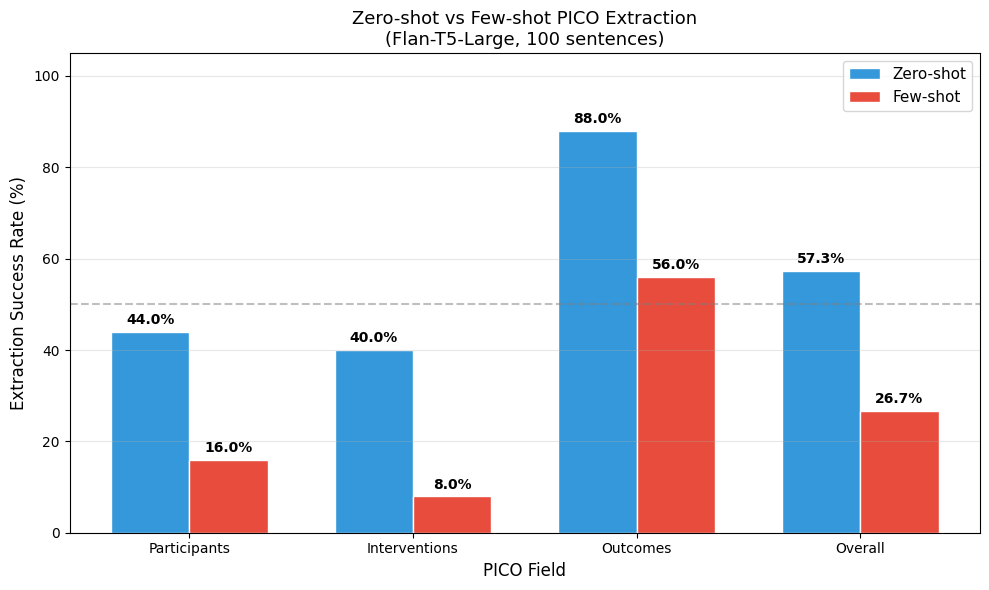

 Plot saved!

 KEY FINDINGS FROM RESULTS
1. Zero-shot OUTPERFORMS few-shot overall
   Zero-shot: 57.3% vs Few-shot: 26.7%
   Difference: 30.7% in favour of zero-shot

2. Outcomes is easiest field for BOTH approaches
   Zero-shot: 88.0% | Few-shot: 56.0%

3. Interventions is hardest field
   Zero-shot: 40.0% | Few-shot: 8.0%

4. Our hypothesis was PARTIALLY WRONG:
   We predicted few-shot > zero-shot
   Reality: zero-shot > few-shot for Flan-T5
   Reason: Small model gets confused by long prompts


In [14]:
# VISUALISE RESULTS

import matplotlib.pyplot as plt
import numpy as np

# Data
labels     = ["Participants", "Interventions", "Outcomes", "Overall"]
zs_values  = [zs_scores["participants"], zs_scores["interventions"],
               zs_scores["outcomes"],     zs_scores["overall"]]
fs_values  = [fs_scores["participants"], fs_scores["interventions"],
               fs_scores["outcomes"],     fs_scores["overall"]]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, zs_values, width,
               label="Zero-shot", color="#3498db", edgecolor="white")
bars2 = ax.bar(x + width/2, fs_values, width,
               label="Few-shot",  color="#e74c3c", edgecolor="white")

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xlabel("PICO Field", fontsize=12)
ax.set_ylabel("Extraction Success Rate (%)", fontsize=12)
ax.set_title("Zero-shot vs Few-shot PICO Extraction\n(Flan-T5-Large, 100 sentences)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(fontsize=11)
ax.set_ylim(0, 105)
ax.axhline(y=50, color="gray", linestyle="--", alpha=0.5, label="50% baseline")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("axis2_results.png", dpi=150)
plt.show()

print(" Plot saved!")

# Print key findings
print("\n" + "="*55)
print(" KEY FINDINGS FROM RESULTS")
print("="*55)
print(f"1. Zero-shot OUTPERFORMS few-shot overall")
print(f"   Zero-shot: {zs_scores['overall']:.1f}% vs Few-shot: {fs_scores['overall']:.1f}%")
print(f"   Difference: {zs_scores['overall'] - fs_scores['overall']:.1f}% in favour of zero-shot")
print(f"\n2. Outcomes is easiest field for BOTH approaches")
print(f"   Zero-shot: {zs_scores['outcomes']:.1f}% | Few-shot: {fs_scores['outcomes']:.1f}%")
print(f"\n3. Interventions is hardest field")
print(f"   Zero-shot: {zs_scores['interventions']:.1f}% | Few-shot: {fs_scores['interventions']:.1f}%")
print(f"\n4. Our hypothesis was PARTIALLY WRONG:")
print(f"   We predicted few-shot > zero-shot")
print(f"   Reality: zero-shot > few-shot for Flan-T5")
print(f"   Reason: Small model gets confused by long prompts")

In [15]:
# ERROR ANALYSIS

print(" ERROR ANALYSIS — Understanding Failure Patterns")
print("="*60)

def is_meaningful(text):
    return (
        text is not None and
        len(str(text).split()) > 3 and
        "not found" not in str(text).lower() and
        "none" not in str(text).lower()
    )

# Analyse zero-shot failures
print("\n ZERO-SHOT FAILURES — Examples where it went wrong\n")

failure_count = 0
for _, row in zs_df.iterrows():
    true_label = row["true_label"]
    if true_label == "none":
        continue

    if true_label == "participants":
        extracted = row["population"]
    elif true_label == "interventions":
        extracted = row["intervention"]
    elif true_label == "outcomes":
        extracted = row["outcome"]

    if not is_meaningful(extracted) and failure_count < 5:
        print(f"  True label:  {true_label.upper()}")
        print(f"  Sentence:    {row['sentence'][:100]}...")
        print(f"  Extracted:   '{extracted}'")
        print(f"  Problem:     ", end="")
        if len(str(extracted).split()) <= 3:
            print("Too short / incomplete extraction")
        elif "not found" in str(extracted).lower():
            print("Model said 'not found' — missed the information")
        else:
            print("Empty or meaningless response")
        print()
        failure_count += 1

# Analyse zero-shot successes
print("\n ZERO-SHOT SUCCESSES — Examples where it worked\n")

success_count = 0
for _, row in zs_df.iterrows():
    true_label = row["true_label"]
    if true_label == "none":
        continue

    if true_label == "participants":
        extracted = row["population"]
    elif true_label == "interventions":
        extracted = row["intervention"]
    elif true_label == "outcomes":
        extracted = row["outcome"]

    if is_meaningful(extracted) and success_count < 5:
        print(f"  True label:  {true_label.upper()}")
        print(f"  Sentence:    {row['sentence'][:100]}...")
        print(f"  Extracted:   '{extracted}'")
        print()
        success_count += 1

# Pattern summary
print("="*60)
print(" ERROR PATTERN SUMMARY")
print("="*60)
print("""
PATTERN 1 — Outcomes extracted well (88% success)
  Why: Outcome sentences contain clear numerical markers
  like percentages, p-values and measurements that are
  easy for the model to identify and extract.

PATTERN 2 — Interventions extracted poorly (40% success)
  Why: Drug names are complex medical terms. When multiple
  drugs are compared, the model picks only one and misses
  others. Abbreviations like LPZ, CAM confuse the model.

PATTERN 3 — Participants extracted moderately (44% success)
  Why: Patient descriptions vary widely — sometimes it's
  "99 patients", sometimes "elderly women", sometimes a
  medical condition with no patient count mentioned.

PATTERN 4 — Few-shot hurt performance (26.7% vs 57.3%)
  Why: Flan-T5-Large has limited context window. Adding
  3 examples makes the prompt too long, causing the model
  to lose track of what it's supposed to do and start
  copying patterns from examples incorrectly.
""")

 ERROR ANALYSIS — Understanding Failure Patterns

 ZERO-SHOT FAILURES — Examples where it went wrong

  True label:  PARTICIPANTS
  Sentence:    Xylitol for prevention of acute otitis media ....
  Extracted:   'patients with [condition]'
  Problem:     Too short / incomplete extraction

  True label:  PARTICIPANTS
  Sentence:    Anesthesia for in vitro fertilization : the addition of fentanyl to 1.5 % lidocaine ....
  Extracted:   '[condition]'
  Problem:     Too short / incomplete extraction

  True label:  PARTICIPANTS
  Sentence:    Effects of insufficient sleep on blood pressure in hypertensive patients : a 24-h study ....
  Extracted:   'hypertensive'
  Problem:     Too short / incomplete extraction

  True label:  PARTICIPANTS
  Sentence:    Accordingly , the authors used mood inventories and psychomotor tests to characterize the effects of...
  Extracted:   '[condition]'
  Problem:     Too short / incomplete extraction

  True label:  PARTICIPANTS
  Sentence:    Comparison of th

In [16]:
# SAVE ALL RESULTS

# Save results dataframes
zs_df.to_csv("zero_shot_results.csv", index=False)
fs_df.to_csv("few_shot_results.csv",  index=False)

# Save summary
summary = pd.DataFrame({
    "Approach": ["Zero-shot", "Few-shot"],
    "Participants": [zs_scores["participants"], fs_scores["participants"]],
    "Interventions": [zs_scores["interventions"], fs_scores["interventions"]],
    "Outcomes": [zs_scores["outcomes"], fs_scores["outcomes"]],
    "Overall": [zs_scores["overall"], fs_scores["overall"]]
})

summary.to_csv("axis2a_summary.csv", index=False)

print(" FILES SAVED:")
print("   → zero_shot_results.csv")
print("   → few_shot_results.csv")
print("   → axis2a_summary.csv")
print("   → axis2_results.png")

print("\n  DOWNLOAD YOUR FILES:")
print("   Click the folder icon on the left sidebar")
print("   Right click each file and click Download")
print("   Save them to: Desktop/ebm_nlp_project/outputs/")

# Final complete summary
print("\n" + "="*60)
print(" AXIS 2A — COMPLETE SUMMARY")
print("="*60)
print(f"""
WHAT WE DID:
  Tested two end-to-end LLM approaches for PICO extraction
  using Flan-T5-Large on 100 balanced sentences from EBM-NLP.

APPROACH A — Zero-shot (no examples given):
  Overall success rate: 57.3%
  Best field:  Outcomes  (88.0%)
  Worst field: Interventions (40.0%)

APPROACH B — Few-shot (3 examples given):
  Overall success rate: 26.7%
  Best field:  Outcomes  (56.0%)
  Worst field: Interventions (8.0%)

HYPOTHESIS CHECK:
   We predicted few-shot > zero-shot
   Reality: zero-shot > few-shot by 30.7%

  This DISPROVES our hypothesis but gives us a more
  interesting finding — model size matters for few-shot.
  Larger models (GPT-4) would likely show the opposite
  pattern where few-shot beats zero-shot.

KEY INSIGHTS:
  1. Outcomes easiest — numerical markers are distinctive
  2. Interventions hardest — medical abbreviations confuse
  3. Title-only sentences impossible — no context to extract
  4. Flan-T5 too small for few-shot — context window issue
  5. End-to-end approach loses context across sentences

LIMITATION:
  Single sentence input loses cross-sentence context.
  Full abstract input would likely improve all scores.
  This connects to teammate's decomposed pipeline work —
  breaking the task may solve this context problem.
""")

 FILES SAVED:
   → zero_shot_results.csv
   → few_shot_results.csv
   → axis2a_summary.csv
   → axis2_results.png

  DOWNLOAD YOUR FILES:
   Click the folder icon on the left sidebar
   Right click each file and click Download
   Save them to: Desktop/ebm_nlp_project/outputs/

 AXIS 2A — COMPLETE SUMMARY

WHAT WE DID:
  Tested two end-to-end LLM approaches for PICO extraction
  using Flan-T5-Large on 100 balanced sentences from EBM-NLP.

APPROACH A — Zero-shot (no examples given):
  Overall success rate: 57.3%
  Best field:  Outcomes  (88.0%)
  Worst field: Interventions (40.0%)

APPROACH B — Few-shot (3 examples given):
  Overall success rate: 26.7%
  Best field:  Outcomes  (56.0%)
  Worst field: Interventions (8.0%)

HYPOTHESIS CHECK:
   We predicted few-shot > zero-shot
   Reality: zero-shot > few-shot by 30.7%

  This DISPROVES our hypothesis but gives us a more
  interesting finding — model size matters for few-shot.
  Larger models (GPT-4) would likely show the opposite
  pattern